In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

chart_path = "reports/charts"
os.makedirs(chart_path, exist_ok=True)

print("Setup complete")

Setup complete


In [2]:
fund_master = pd.read_csv("data/processed/01_fund_master_cleaned.csv")
nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("data/processed/03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv("data/processed/04_monthly_sip_inflows_cleaned.csv")
category_inflows = pd.read_csv("data/processed/05_category_inflows_cleaned.csv")
folio = pd.read_csv("data/processed/06_industry_folio_count_cleaned.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")
holdings = pd.read_csv("data/processed/09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv("data/processed/10_benchmark_indices_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category_inflows["month"] = pd.to_datetime(category_inflows["month"])
folio["month"] = pd.to_datetime(folio["month"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
holdings["portfolio_date"] = pd.to_datetime(holdings["portfolio_date"])

print("All datasets loaded")

All datasets loaded


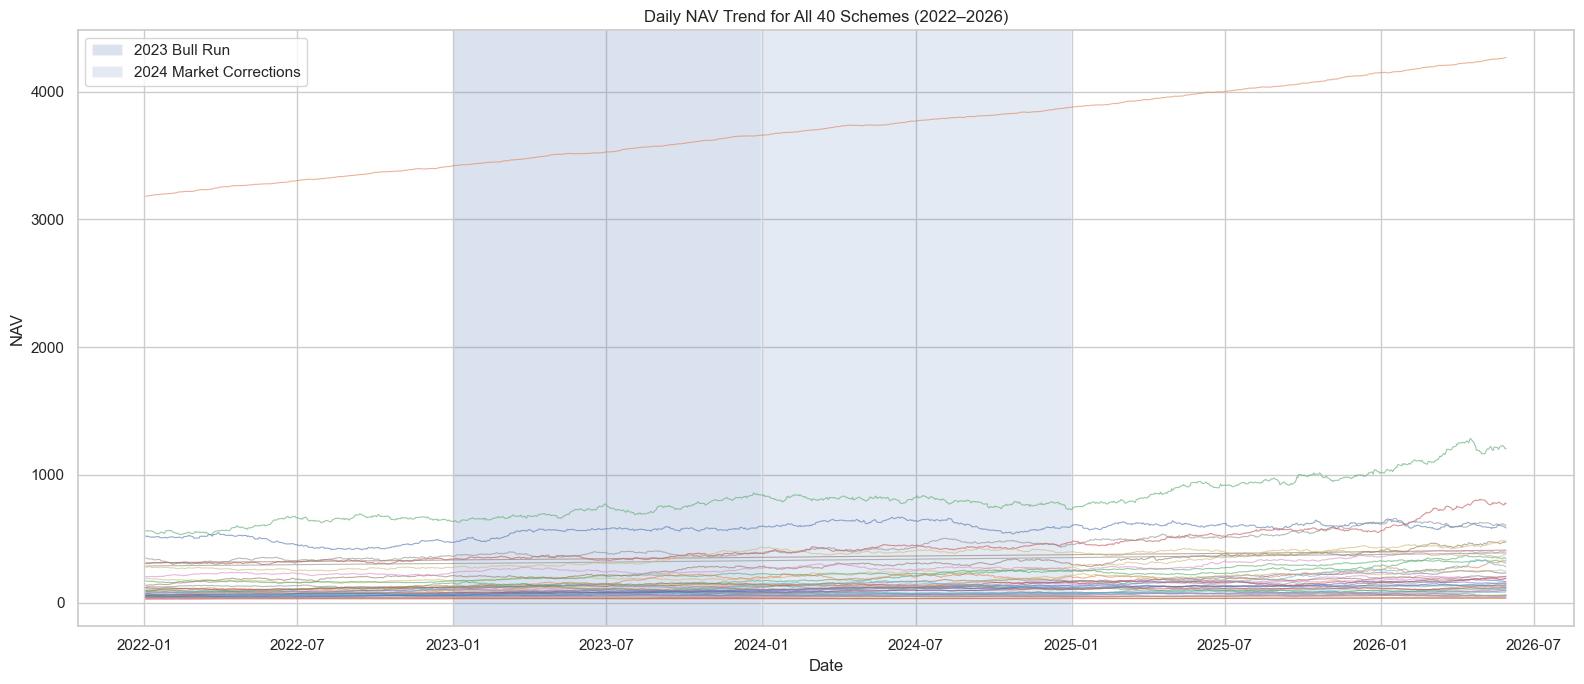

In [3]:
nav_merged = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

plt.figure(figsize=(16, 7))

for scheme in nav_merged["scheme_name"].unique():
    temp = nav_merged[nav_merged["scheme_name"] == scheme]
    plt.plot(temp["date"], temp["nav"], linewidth=0.8, alpha=0.6)

plt.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"), alpha=0.2, label="2023 Bull Run")
plt.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"), alpha=0.15, label="2024 Market Corrections")

plt.title("Daily NAV Trend for All 40 Schemes (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.savefig("reports/charts/01_nav_trend_all_schemes.png", dpi=300)
plt.show()

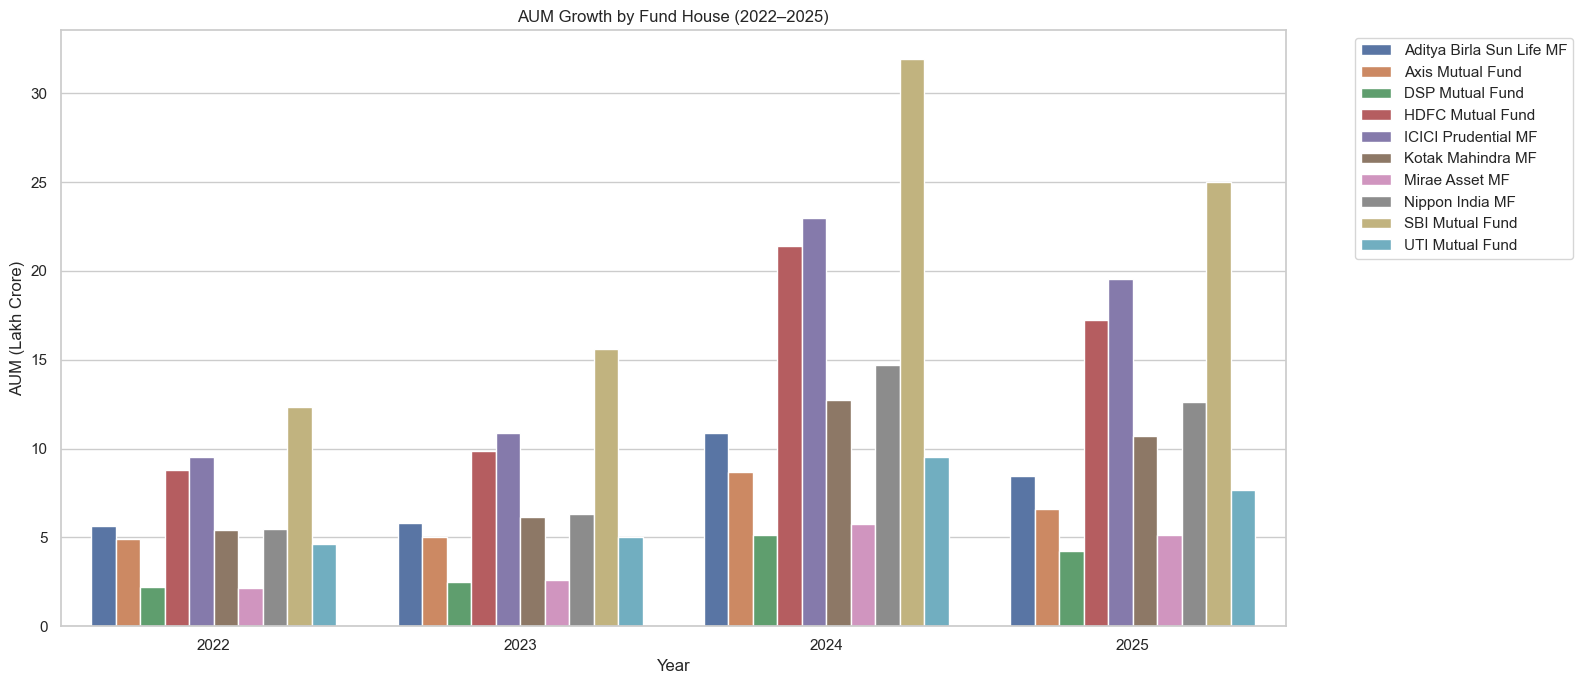

In [4]:
aum["year"] = aum["date"].dt.year

aum_yearly = aum.groupby(["year", "fund_house"])["aum_lakh_crore"].sum().reset_index()
aum_yearly = aum_yearly[aum_yearly["year"].between(2022, 2025)]

plt.figure(figsize=(16, 7))
sns.barplot(data=aum_yearly, x="year", y="aum_lakh_crore", hue="fund_house")

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("reports/charts/02_aum_growth_by_fund_house.png", dpi=300)
plt.show()

/var/folders/wq/qjtlzxqd7230xkvd70xf0jdr0000gn/T/ipykernel_32848/139076642.py:18: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wq/qjtlzxqd7230xkvd70xf0jdr0000gn/T/ipykernel_32848/139076642.py:19: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig("reports/charts/03_sip_inflow_trend.png", dpi=300)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


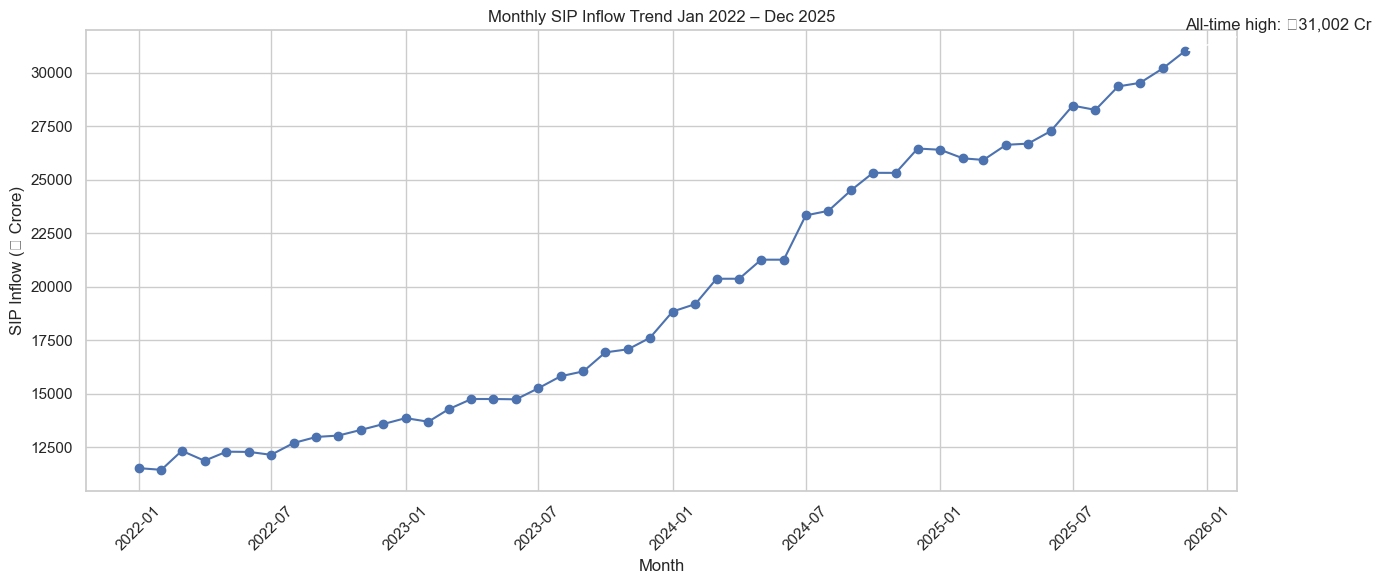

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(sip["month"], sip["sip_inflow_crore"], marker="o")

max_idx = sip["sip_inflow_crore"].idxmax()

plt.annotate(
    f"All-time high: ₹{sip.loc[max_idx, 'sip_inflow_crore']:,.0f} Cr",
    xy=(sip.loc[max_idx, "month"], sip.loc[max_idx, "sip_inflow_crore"]),
    xytext=(sip.loc[max_idx, "month"], sip.loc[max_idx, "sip_inflow_crore"] + 1000),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflow Trend Jan 2022 – Dec 2025")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/charts/03_sip_inflow_trend.png", dpi=300)
plt.show()

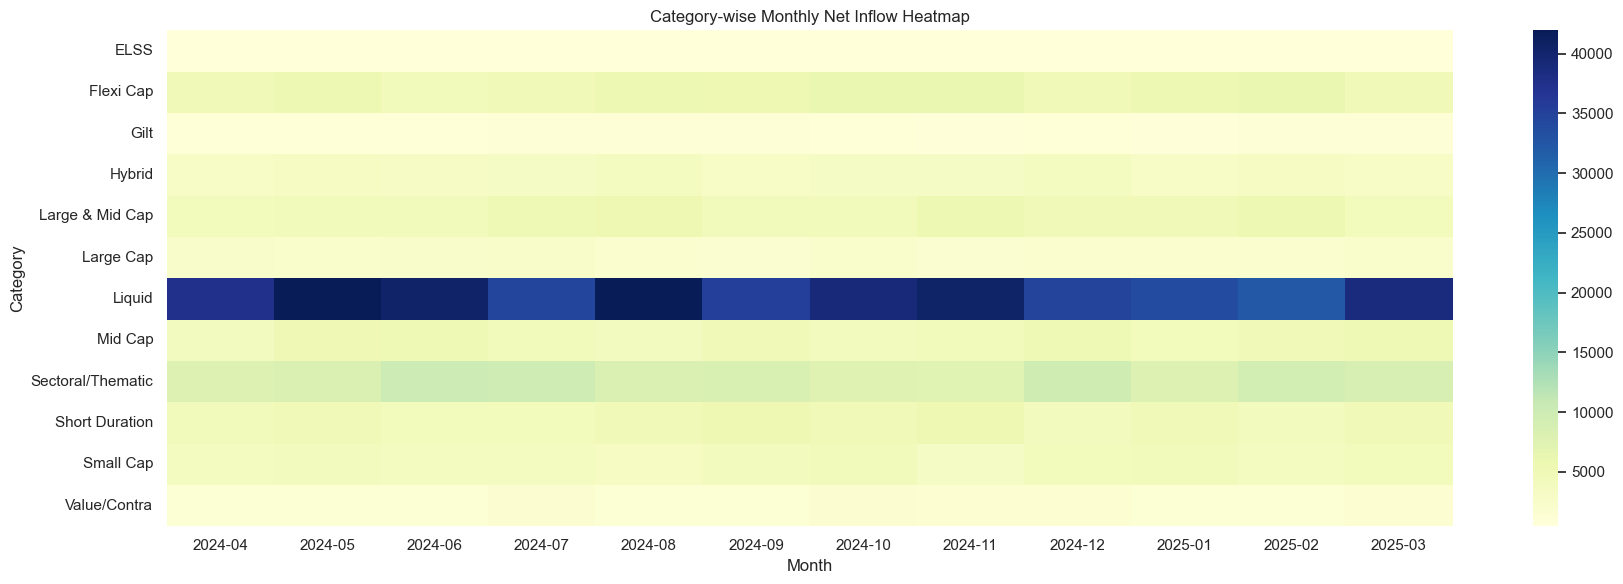

In [6]:
category_inflows["month_str"] = category_inflows["month"].dt.strftime("%Y-%m")

category_pivot = category_inflows.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(18, 6))
sns.heatmap(category_pivot, cmap="YlGnBu")

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("reports/charts/04_category_inflow_heatmap.png", dpi=300)
plt.show()

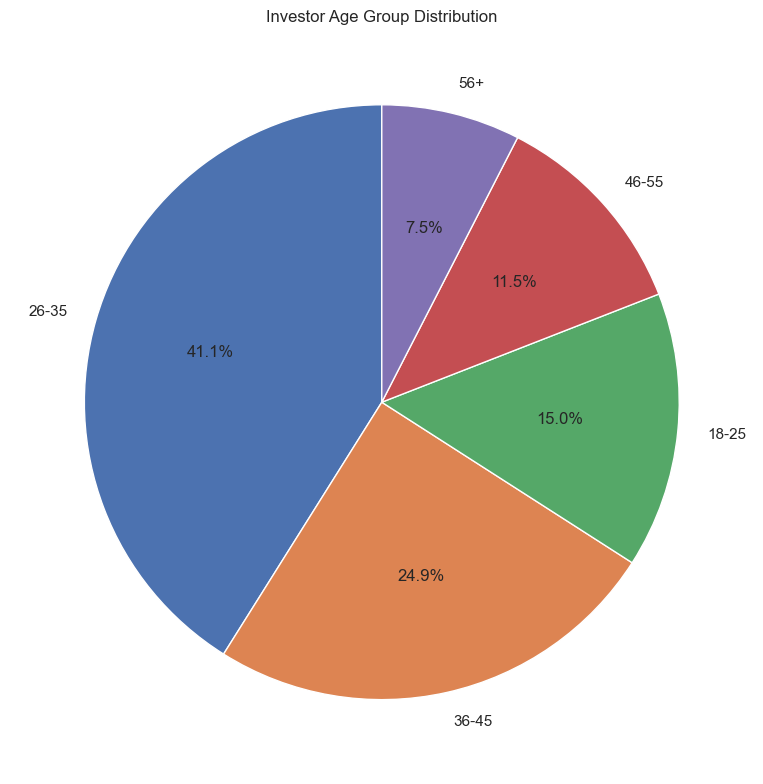

In [7]:
age_dist = transactions["age_group"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(age_dist.values, labels=age_dist.index, autopct="%1.1f%%", startangle=90)
plt.title("Investor Age Group Distribution")
plt.tight_layout()
plt.savefig("reports/charts/05_age_group_distribution.png", dpi=300)
plt.show()

/var/folders/wq/qjtlzxqd7230xkvd70xf0jdr0000gn/T/ipykernel_32848/3577680198.py:9: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wq/qjtlzxqd7230xkvd70xf0jdr0000gn/T/ipykernel_32848/3577680198.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig("reports/charts/06_sip_amount_by_age_group.png", dpi=300)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


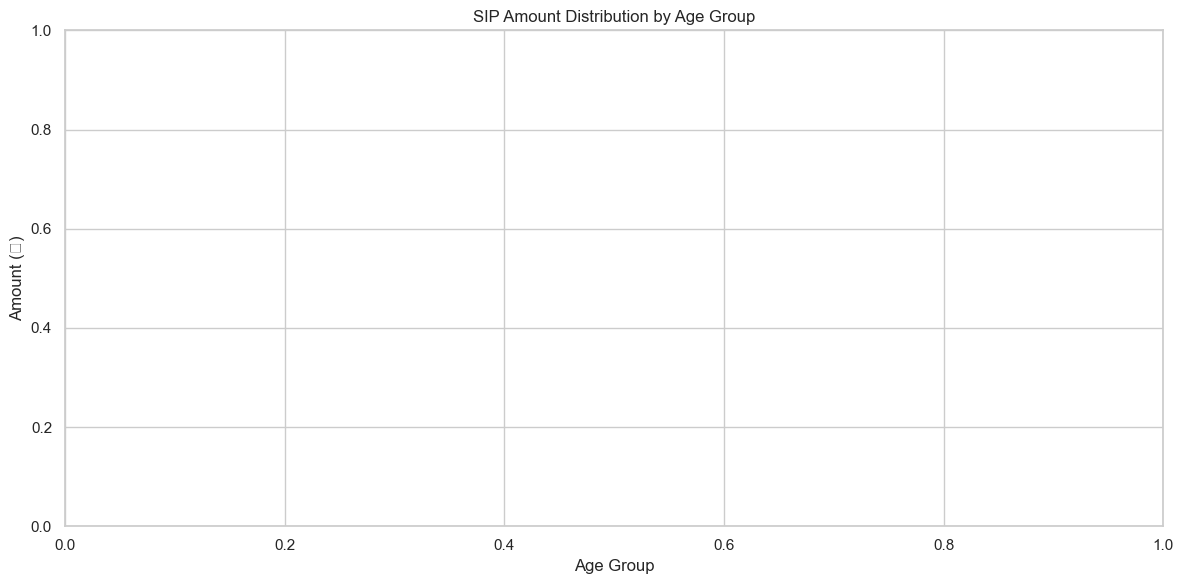

In [8]:
sip_txn = transactions[transactions["transaction_type"] == "SIP"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr")

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (₹)")
plt.tight_layout()
plt.savefig("reports/charts/06_sip_amount_by_age_group.png", dpi=300)
plt.show()

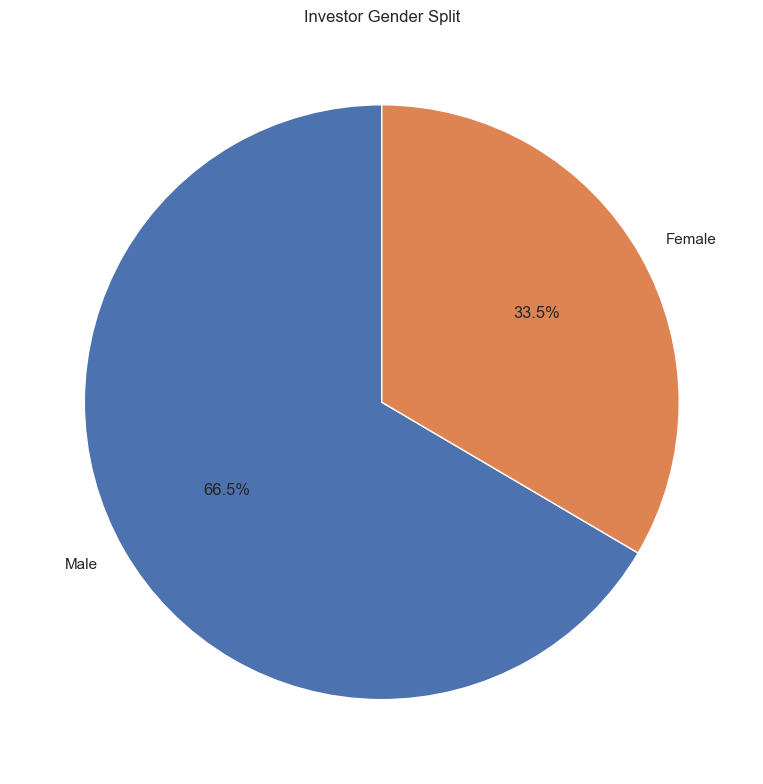

In [9]:
gender_dist = transactions["gender"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_dist.values, labels=gender_dist.index, autopct="%1.1f%%", startangle=90)
plt.title("Investor Gender Split")
plt.tight_layout()
plt.savefig("reports/charts/07_gender_split.png", dpi=300)
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

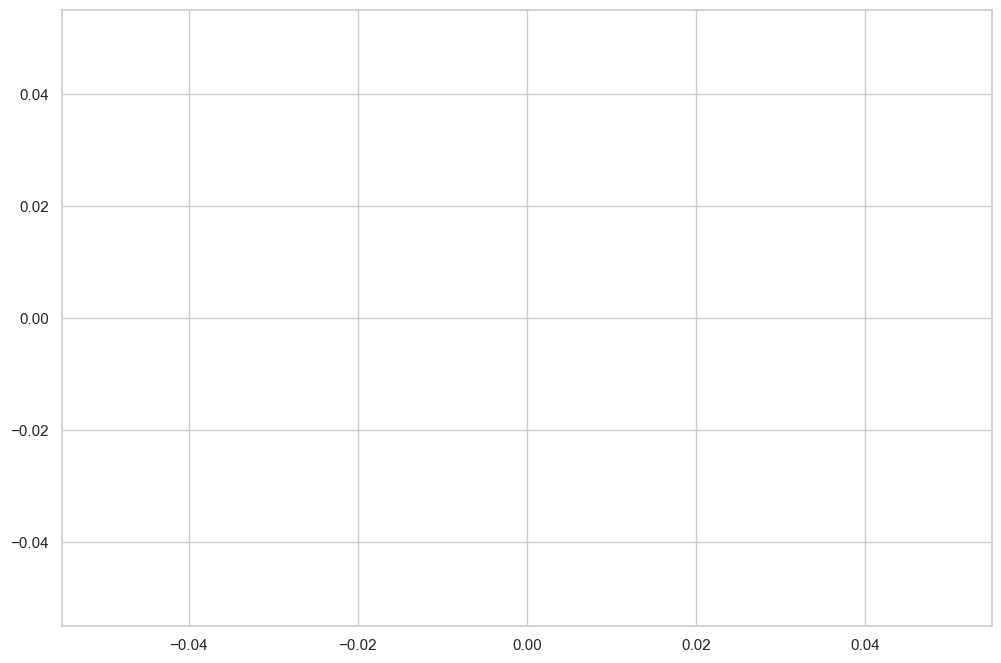

In [10]:
state_sip = sip_txn.groupby("state")["amount_inr"].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
state_sip.plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("reports/charts/08_sip_amount_by_state.png", dpi=300)
plt.show()

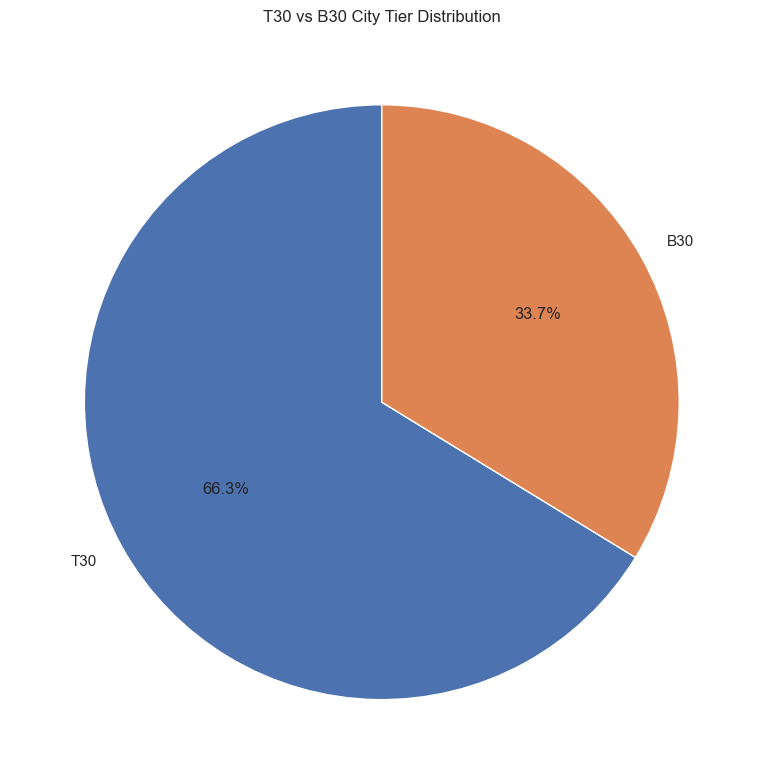

In [11]:
city_tier_dist = transactions["city_tier"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(city_tier_dist.values, labels=city_tier_dist.index, autopct="%1.1f%%", startangle=90)
plt.title("T30 vs B30 City Tier Distribution")
plt.tight_layout()
plt.savefig("reports/charts/09_city_tier_distribution.png", dpi=300)
plt.show()

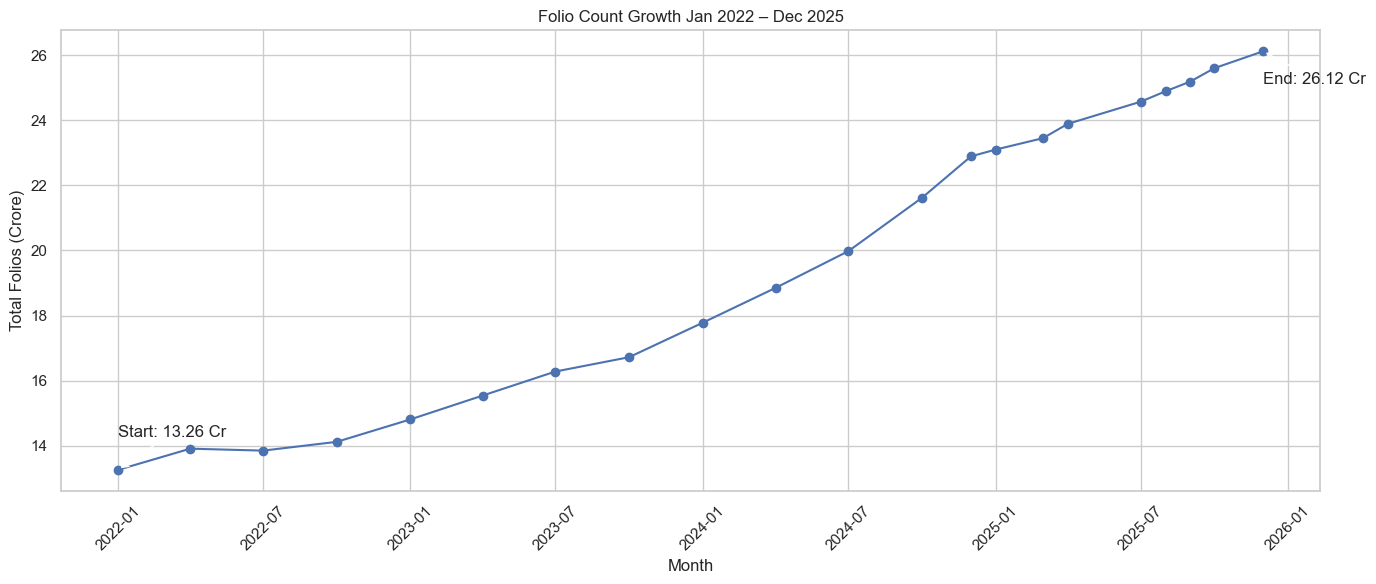

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(folio["month"], folio["total_folios_crore"], marker="o")

plt.annotate(
    f"Start: {folio.iloc[0]['total_folios_crore']} Cr",
    xy=(folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"]),
    xytext=(folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"] + 1),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f"End: {folio.iloc[-1]['total_folios_crore']} Cr",
    xy=(folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"]),
    xytext=(folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"] - 1),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Folio Count Growth Jan 2022 – Dec 2025")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/charts/10_folio_count_growth.png", dpi=300)
plt.show()

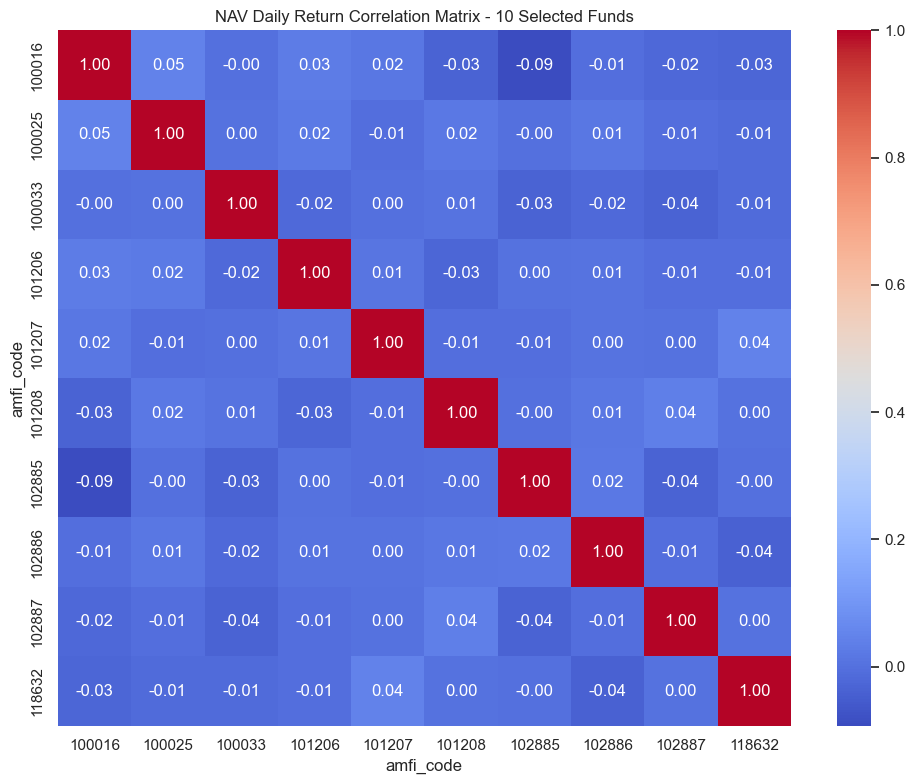

In [13]:
selected_codes = nav["amfi_code"].unique()[:10]

nav_10 = nav[nav["amfi_code"].isin(selected_codes)]

nav_pivot = nav_10.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_pivot.pct_change().dropna()

corr_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("NAV Daily Return Correlation Matrix - 10 Selected Funds")
plt.tight_layout()
plt.savefig("reports/charts/11_nav_return_correlation.png", dpi=300)
plt.show()

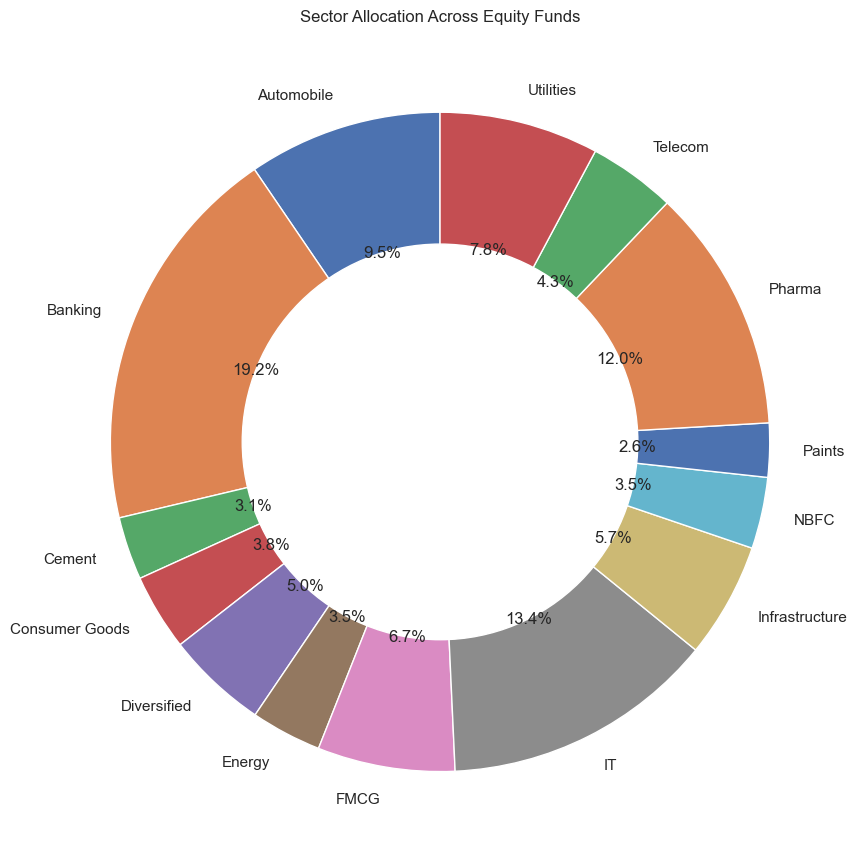

In [14]:
sector_alloc = holdings.groupby("sector")["weight_pct"].sum().reset_index()

plt.figure(figsize=(9, 9))

plt.pie(
    sector_alloc["weight_pct"],
    labels=sector_alloc["sector"],
    autopct="%1.1f%%",
    startangle=90
)

centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.savefig("reports/charts/12_sector_allocation_donut.png", dpi=300)
plt.show()

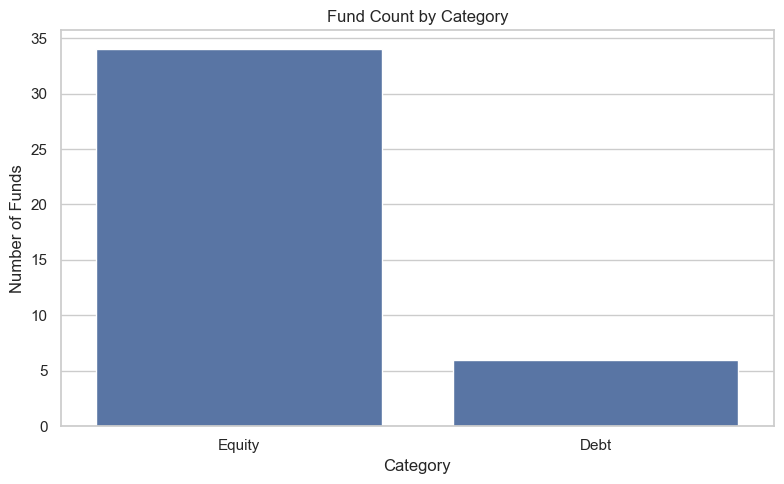

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=fund_master, x="category")

plt.title("Fund Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Funds")
plt.tight_layout()
plt.savefig("reports/charts/13_fund_count_by_category.png", dpi=300)
plt.show()

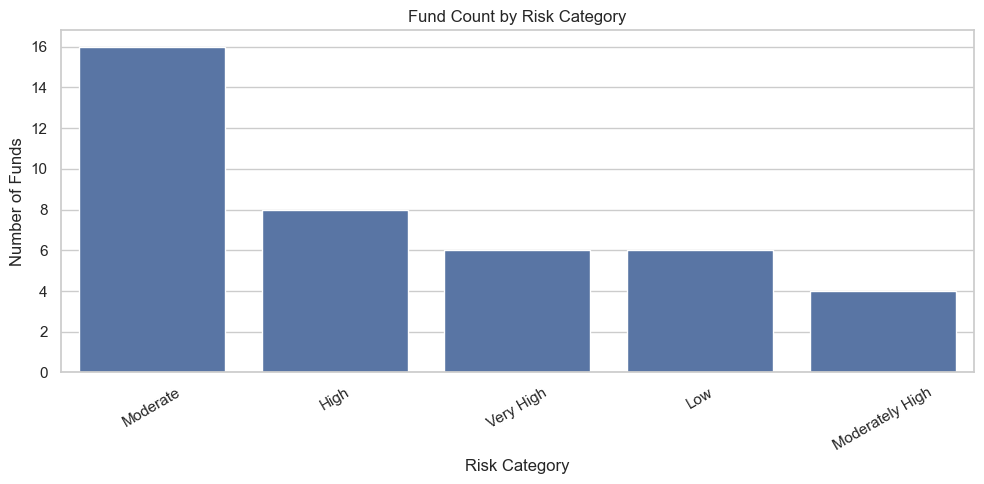

In [16]:
plt.figure(figsize=(10, 5))
sns.countplot(data=fund_master, x="risk_category", order=fund_master["risk_category"].value_counts().index)

plt.title("Fund Count by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("reports/charts/14_risk_category_distribution.png", dpi=300)
plt.show()

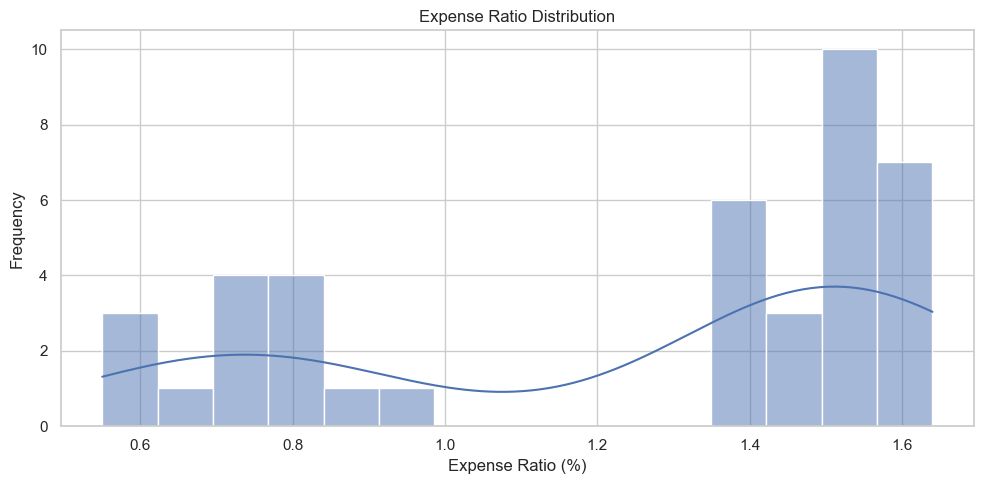

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(performance["expense_ratio_pct"], bins=15, kde=True)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("reports/charts/15_expense_ratio_distribution.png", dpi=300)
plt.show()

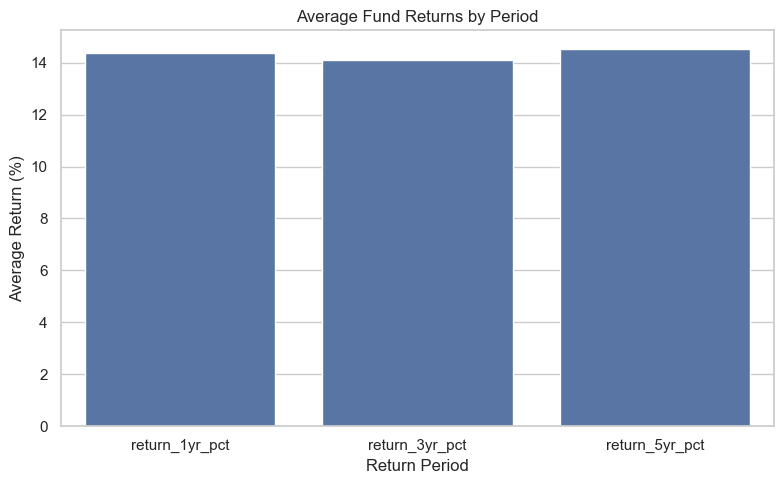

In [18]:
return_cols = ["return_1yr_pct", "return_3yr_pct", "return_5yr_pct"]

avg_returns = performance[return_cols].mean().reset_index()
avg_returns.columns = ["Return Period", "Average Return"]

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_returns, x="Return Period", y="Average Return")

plt.title("Average Fund Returns by Period")
plt.xlabel("Return Period")
plt.ylabel("Average Return (%)")
plt.tight_layout()
plt.savefig("reports/charts/16_average_returns.png", dpi=300)
plt.show()

/var/folders/wq/qjtlzxqd7230xkvd70xf0jdr0000gn/T/ipykernel_32848/2407599196.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wq/qjtlzxqd7230xkvd70xf0jdr0000gn/T/ipykernel_32848/2407599196.py:14: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig("reports/charts/17_aum_vs_expense_ratio.png", dpi=300)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


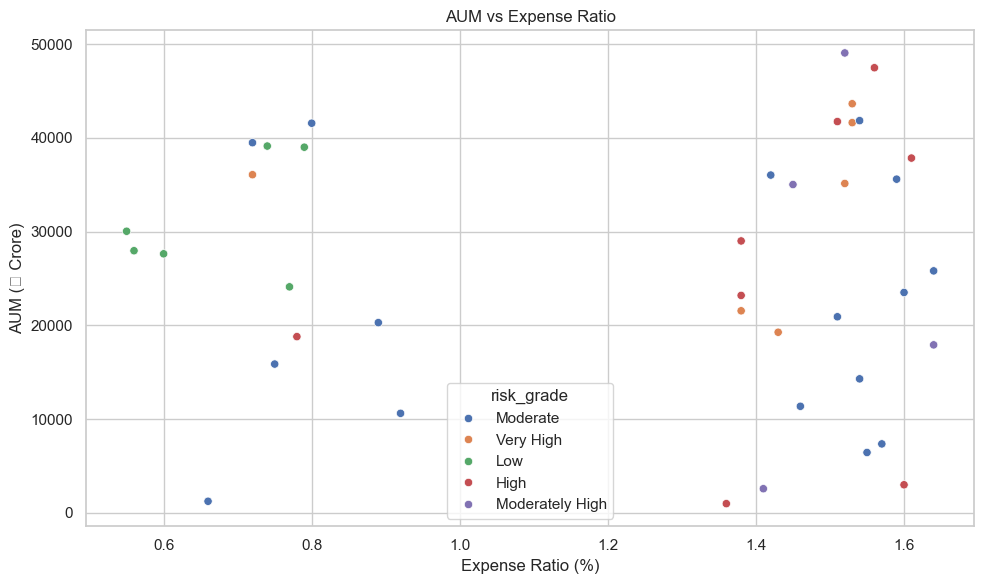

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=performance,
    x="expense_ratio_pct",
    y="aum_crore",
    hue="risk_grade"
)

plt.title("AUM vs Expense Ratio")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("AUM (₹ Crore)")
plt.tight_layout()
plt.savefig("reports/charts/17_aum_vs_expense_ratio.png", dpi=300)
plt.show()

In [20]:
os.listdir("reports/charts")

['02_aum_growth_by_fund_house.png',
 'category_inflow_heatmap.png',
 '14_risk_category_distribution.png',
 '06_sip_amount_by_age_group.png',
 '15_expense_ratio_distribution.png',
 '10_folio_count_growth.png',
 '13_fund_count_by_category.png',
 '01_nav_trend_all_schemes.png',
 '09_city_tier_distribution.png',
 '12_sector_allocation_donut.png',
 '04_category_inflow_heatmap.png',
 'sip_inflow_trend.png',
 '07_gender_split.png',
 '03_sip_inflow_trend.png',
 '16_average_returns.png',
 '05_age_group_distribution.png',
 '11_nav_return_correlation.png',
 '17_aum_vs_expense_ratio.png']

## Insight 1
NAV trends show visible growth across most schemes during 2023, indicating a broad market uptrend.